# Superstore Sales & Profitability Analysis

## Overview

This project analyzes the Superstore sales dataset to evaluate sales performance, profitability, customer behavior, product performance, and regional trends.

The analysis focuses on identifying patterns in sales and profit, understanding the impact of discounts on profitability, and generating business insights that could support data-driven decision-making.

## Objectives

- Analyze overall sales and profitability.
- Identify the best-performing products and categories.
- Analyze sales performance over time.
- Identify the most valuable customers.
- Compare regional performance.
- Evaluate the relationship between discounts and profitability.
- Generate actionable business recommendations.

## Tools

- Python
- Pandas
- NumPy
- Matplotlib

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Sample - Superstore.csv", encoding = "latin-1")

In [2]:
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Initial Data Inspection

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 3. Data Cleaning

In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## Data Features

In [5]:
df["Month"] = df["Order Date"].dt.month
df["Year"] = df["Order Date"].dt.year


## Dataset Overview

In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()


Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Month', 'Year']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994

### Descriptive Statistics

In [7]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Month,Year
count,"9,994.00",9994,9994,"9,994.00","9,994.00","9,994.00","9,994.00","9,994.00","9,994.00","9,994.00"
mean,"4,997.50",2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,"55,190.38",229.86,3.79,0.16,28.66,7.81,"2,015.72"
min,1.00,2014-01-03 00:00:00,2014-01-07 00:00:00,"1,040.00",0.44,1.00,0.00,"-6,599.98",1.00,"2,014.00"
25%,"2,499.25",2015-05-23 00:00:00,2015-05-27 00:00:00,"23,223.00",17.28,2.00,0.00,1.73,5.00,"2,015.00"
50%,"4,997.50",2016-06-26 00:00:00,2016-06-29 00:00:00,"56,430.50",54.49,3.00,0.20,8.67,9.00,"2,016.00"
75%,"7,495.75",2017-05-14 00:00:00,2017-05-18 00:00:00,"90,008.00",209.94,5.00,0.20,29.36,11.00,"2,017.00"
max,"9,994.00",2017-12-30 00:00:00,2018-01-05 00:00:00,"99,301.00","22,638.48",14.00,0.80,"8,399.98",12.00,"2,017.00"
std,"2,885.16",NaN,NaN,"32,063.69",623.25,2.23,0.21,234.26,3.28,1.12


### Missing Values and Duplicates

In [8]:
print("Missing values:")
print(df.isna().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Month            0
Year             0
dtype: int64

Duplicate rows: 0


### Categorical Variables

In [9]:
categorical_columns = ["Category", "Sub-Category", "Segment", "Region"]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

df["Category"].value_counts()


Category:
['Furniture' 'Office Supplies' 'Technology']

Sub-Category:
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']

Segment:
['Consumer' 'Corporate' 'Home Office']

Region:
['South' 'West' 'Central' 'East']


Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

In [10]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]

df[numeric_columns].describe()

,Sales,Quantity,Discount,Profit
count,"9,994.00","9,994.00","9,994.00","9,994.00"
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,"-6,599.98"
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,"22,638.48",14.00,0.80,"8,399.98"


## 4. Feature Engineering

In [11]:
df["Profit Margin"] = ((df["Profit"] / df["Sales"]) * 100).round(2)


In [12]:
df["Month Name"] = pd.to_datetime(
    df["Month"], 
    format="%m"
).dt.month_name()

df["Month Name"] = pd.Categorical(
    df["Month Name"],
    categories=[
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ],
    ordered=True
)

In [13]:
df["Profit per Unit"] = (
    df["Profit"] / df["Quantity"]
).round(2)

In [14]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Month,Year,Profit Margin,Month Name,Profit per Unit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,11,2016,16.00,November,20.96
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,11,2016,30.00,November,73.19
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,6,2016,47.00,June,3.44
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,10,2015,-40.00,October,-76.61
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,10,2015,11.25,October,1.26


## 5. Exploratory Data Analysis

### 5.1 Product Analysis

In [15]:
Top_10_Products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10).reset_index()
Top_10_Products

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,"61,599.82"
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,"27,453.38"
2,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48"
3,HON 5400 Series Task Chairs for Big and Tall,"21,870.58"
4,GBC DocuBind TL300 Electric Binding System,"19,823.48"
5,GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50"
6,Hewlett Packard LaserJet 3310 Copier,"18,839.69"
7,HP Designjet T520 Inkjet Large Format Printer ...,"18,374.90"
8,GBC DocuBind P400 Electric Binding System,"17,965.07"
9,High Speed Automatic Electric Letter Opener,"17,030.31"


In [16]:
Top_10_Products_Profit = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10).reset_index()
Top_10_Products_Profit

,Product Name,Profit
0,Canon imageCLASS 2200 Advanced Copier,"25,199.93"
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,"7,753.04"
2,Hewlett Packard LaserJet 3310 Copier,"6,983.88"
3,Canon PC1060 Personal Laser Copier,"4,570.93"
4,HP Designjet T520 Inkjet Large Format Printer ...,"4,094.98"
5,Ativa V4110MDD Micro-Cut Shredder,"3,772.95"
6,"3D Systems Cube Printer, 2nd Generation, Magenta","3,717.97"
7,Plantronics Savi W720 Multi-Device Wireless He...,"3,696.28"
8,Ibico EPK-21 Electric Binding System,"3,345.28"
9,Zebra ZM400 Thermal Label Printer,"3,343.54"


In [17]:
Top_10_Products_Sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10).reset_index()
Top_10_Products_Profit = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10).reset_index()

Comparison_Table = pd.DataFrame({
    "Rank": range(1, 11),
    "Product (by Sales)": Top_10_Products_Sales["Product Name"],
    "Sales": Top_10_Products_Sales["Sales"],
    "Product (by Profit)": Top_10_Products_Profit["Product Name"],
    "Profit": Top_10_Products_Profit["Profit"]
})

Comparison_Table

,Rank,Product (by Sales),Sales,Product (by Profit),Profit
0,1,Canon imageCLASS 2200 Advanced Copier,"61,599.82",Canon imageCLASS 2200 Advanced Copier,"25,199.93"
1,2,Fellowes PB500 Electric Punch Plastic Comb Bin...,"27,453.38",Fellowes PB500 Electric Punch Plastic Comb Bin...,"7,753.04"
2,3,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48",Hewlett Packard LaserJet 3310 Copier,"6,983.88"
3,4,HON 5400 Series Task Chairs for Big and Tall,"21,870.58",Canon PC1060 Personal Laser Copier,"4,570.93"
4,5,GBC DocuBind TL300 Electric Binding System,"19,823.48",HP Designjet T520 Inkjet Large Format Printer ...,"4,094.98"
5,6,GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50",Ativa V4110MDD Micro-Cut Shredder,"3,772.95"
6,7,Hewlett Packard LaserJet 3310 Copier,"18,839.69","3D Systems Cube Printer, 2nd Generation, Magenta","3,717.97"
7,8,HP Designjet T520 Inkjet Large Format Printer ...,"18,374.90",Plantronics Savi W720 Multi-Device Wireless He...,"3,696.28"
8,9,GBC DocuBind P400 Electric Binding System,"17,965.07",Ibico EPK-21 Electric Binding System,"3,345.28"
9,10,High Speed Automatic Electric Letter Opener,"17,030.31",Zebra ZM400 Thermal Label Printer,"3,343.54"


### 5.2 Category Analysis

In [18]:
category_analysis = df.groupby(["Category" , "Sub-Category"])[["Sales" , "Profit" , "Quantity"]].sum().reset_index()
category_analysis

,Category,Sub-Category,Sales,Profit,Quantity
0,Furniture,Bookcases,"114,880.00","-3,472.56",868
1,Furniture,Chairs,"328,449.10","26,590.17",2356
2,Furniture,Furnishings,"91,705.16","13,059.14",3563
3,Furniture,Tables,"206,965.53","-17,725.48",1241
4,Office Supplies,Appliances,"107,532.16","18,138.01",1729
5,Office Supplies,Art,"27,118.79","6,527.79",3000
6,Office Supplies,Binders,"203,412.73","30,221.76",5974
7,Office Supplies,Envelopes,"16,476.40","6,964.18",906
8,Office Supplies,Fasteners,"3,024.28",949.52,914
9,Office Supplies,Labels,"12,486.31","5,546.25",1400


In [19]:
Category_Summary = df.groupby("Category")[["Sales", "Profit", "Quantity"]].sum().reset_index()
Category_Summary = Category_Summary.sort_values("Sales", ascending= False)
Category_Summary

,Category,Sales,Profit,Quantity
2,Technology,"836,154.03","145,454.95",6939
0,Furniture,"741,999.80","18,451.27",8028
1,Office Supplies,"719,047.03","122,490.80",22906


### 5.3 Temporal Analysis

In [20]:
Sales_Per_Year = df.groupby("Year")[["Sales", "Profit"]].sum().reset_index()
Sales_Per_Year

,Year,Sales,Profit
0,2014,"484,247.50","49,543.97"
1,2015,"470,532.51","61,618.60"
2,2016,"609,205.60","81,795.17"
3,2017,"733,215.26","93,439.27"


In [21]:
Sales_Per_Month = df.groupby("Month Name", observed=True)[["Sales", "Profit"]].sum().reset_index()
Sales_Per_Month

,Month Name,Sales,Profit
0,January,"94,924.84","9,134.45"
1,February,"59,751.25","10,294.61"
2,March,"205,005.49","28,594.69"
3,April,"137,762.13","11,587.44"
4,May,"155,028.81","22,411.31"
5,June,"152,718.68","21,285.80"
6,July,"147,238.10","13,832.66"
7,August,"159,044.06","21,776.94"
8,September,"307,649.95","36,857.48"
9,October,"200,322.98","31,784.04"


In [22]:
Sales_Per_YearandMonth = df.groupby(["Year", "Month Name"], observed=True)[["Sales", "Profit"]].sum().reset_index()
Sales_Per_YearandMonth

,Year,Month Name,Sales,Profit
0,2014,January,"14,236.90","2,450.19"
1,2014,February,"4,519.89",862.31
2,2014,March,"55,691.01",498.73
3,2014,April,"28,295.35","3,488.84"
4,2014,May,"23,648.29","2,738.71"
5,2014,June,"34,595.13","4,976.52"
6,2014,July,"33,946.39",-841.48
7,2014,August,"27,909.47","5,318.10"
8,2014,September,"81,777.35","8,328.10"
9,2014,October,"31,453.39","3,448.26"


### 5.4 Customer Analysis

In [23]:
Top_10_Customer_Sales = df.groupby(["Customer ID","Customer Name", "Segment"])["Sales"].sum().sort_values(ascending=False).reset_index().head(10)
Top_10_Customer_Sales

,Customer ID,Customer Name,Segment,Sales
0,SM-20320,Sean Miller,Home Office,"25,043.05"
1,TC-20980,Tamara Chand,Corporate,"19,052.22"
2,RB-19360,Raymond Buch,Consumer,"15,117.34"
3,TA-21385,Tom Ashbrook,Home Office,"14,595.62"
4,AB-10105,Adrian Barton,Consumer,"14,473.57"
5,KL-16645,Ken Lonsdale,Consumer,"14,175.23"
6,SC-20095,Sanjit Chand,Consumer,"14,142.33"
7,HL-15040,Hunter Lopez,Consumer,"12,873.30"
8,SE-20110,Sanjit Engle,Consumer,"12,209.44"
9,CC-12370,Christopher Conant,Consumer,"12,129.07"


In [24]:
Top_10_Customer_Profit = df.groupby(["Customer ID","Customer Name", "Segment"])["Profit"].sum().sort_values(ascending=False).reset_index().head(10)
Top_10_Customer_Profit

,Customer ID,Customer Name,Segment,Profit
0,TC-20980,Tamara Chand,Corporate,"8,981.32"
1,RB-19360,Raymond Buch,Consumer,"6,976.10"
2,SC-20095,Sanjit Chand,Consumer,"5,757.41"
3,HL-15040,Hunter Lopez,Consumer,"5,622.43"
4,AB-10105,Adrian Barton,Consumer,"5,444.81"
5,TA-21385,Tom Ashbrook,Home Office,"4,703.79"
6,CM-12385,Christopher Martinez,Consumer,"3,899.89"
7,KD-16495,Keith Dawkins,Corporate,"3,038.63"
8,AR-10540,Andy Reiter,Consumer,"2,884.62"
9,DR-12940,Daniel Raglin,Home Office,"2,869.08"


### 5.5 Regional Analysis

In [25]:
Sales_By_Region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False).reset_index()
Sales_By_Region

,Region,Sales
0,West,"725,457.82"
1,East,"678,781.24"
2,Central,"501,239.89"
3,South,"391,721.91"


In [26]:
Profit_By_Region = df.groupby("Region")["Profit"].sum().sort_values(ascending=False).reset_index()
Profit_By_Region

,Region,Profit
0,West,"108,418.45"
1,East,"91,522.78"
2,South,"46,749.43"
3,Central,"39,706.36"


In [27]:
region_comparison = df.groupby("Region")[["Sales", "Profit"]].sum().reset_index()
region_comparison["Profit_Margin"] = region_comparison["Profit"] / region_comparison["Sales"] * 100
region_comparison.sort_values("Sales", ascending=False).round(2)

,Region,Sales,Profit,Profit_Margin
3,West,"725,457.82","108,418.45",14.94
1,East,"678,781.24","91,522.78",13.48
0,Central,"501,239.89","39,706.36",7.92
2,South,"391,721.90","46,749.43",11.93


### 5.6 Discount & Profitability Analysis

In [28]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .mean()
    .reset_index()
)

discount_profit

,Discount,Profit
0,0.00,66.90
1,0.10,96.06
2,0.15,27.29
3,0.20,24.70
4,0.30,-45.68
5,0.32,-88.56
6,0.40,-111.93
7,0.45,-226.65
8,0.50,-310.70
9,0.60,-43.08


### KPIs

In [29]:
Total_Sales = df["Sales"].sum()
Total_Profit = df["Profit"].sum()
Total_Orders = df["Order ID"].nunique()
Total_Customers = df["Customer ID"].nunique()

Average_Order_Value = (
    df.groupby("Order ID")["Sales"]
    .sum()
    .mean()
)

Profit_Margin = (
    Total_Profit / Total_Sales
) * 100

print(
    f"Total Sales: ${Total_Sales:,.2f}\n"
    f"Total Profit: ${Total_Profit:,.2f}\n"
    f"Total Orders: {Total_Orders:,}\n"
    f"Total Customers: {Total_Customers:,}\n"
    f"Average Order Value: ${Average_Order_Value:,.2f}\n"
    f"Profit Margin: {Profit_Margin:.2f}%"
)

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Average Order Value: $458.61
Profit Margin: 12.47%


## 6. Data Visualizations

### Sales Trend

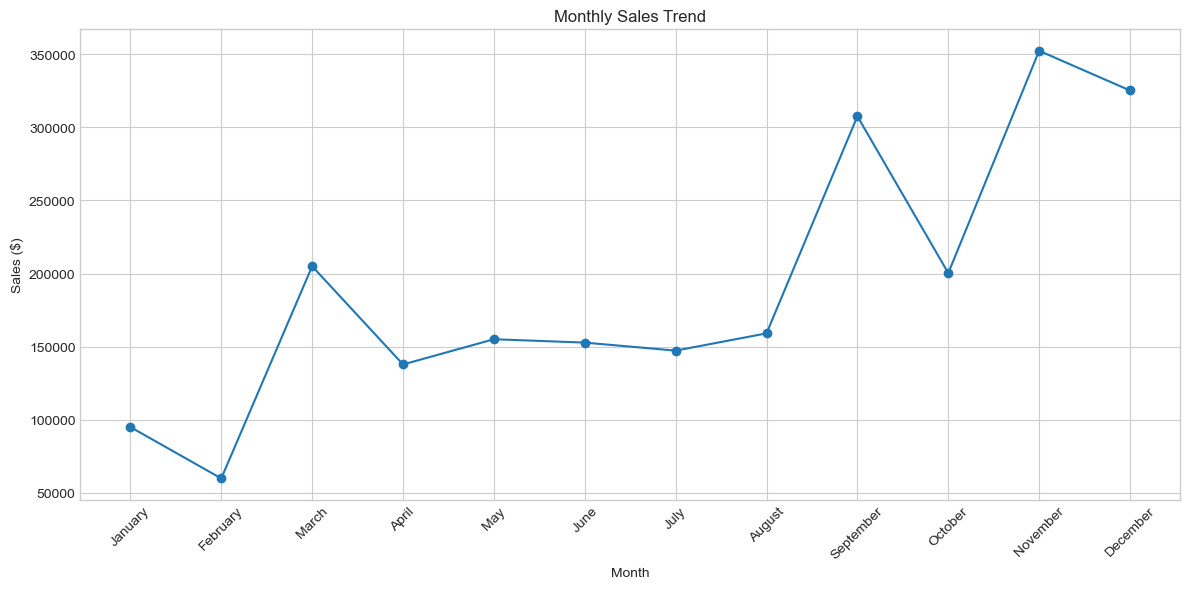

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(Sales_Per_Month["Month Name"], Sales_Per_Month["Sales"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()

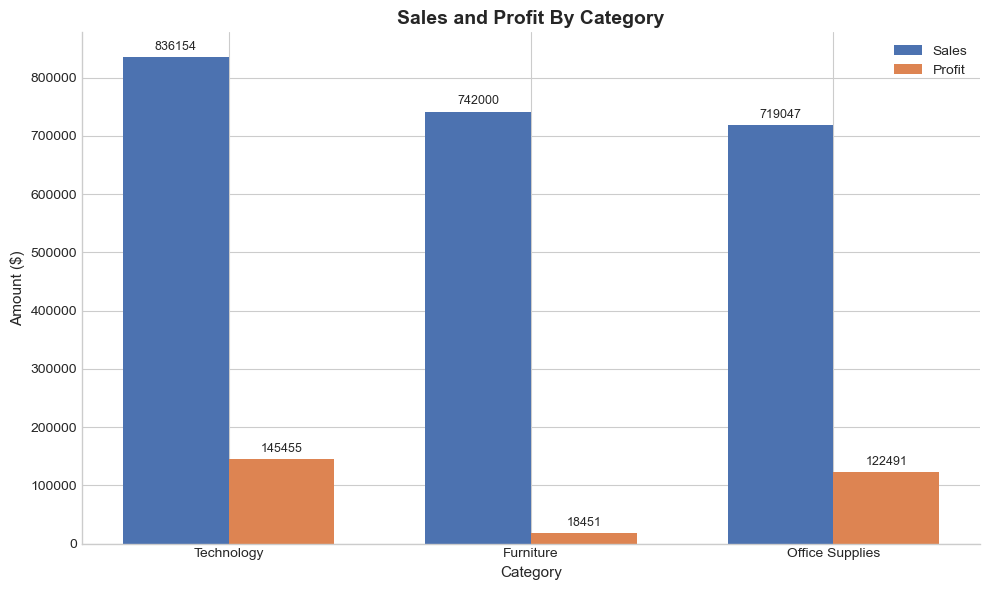

In [31]:
x = np.arange(len(Category_Summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, Category_Summary["Sales"], width, label="Sales", color="#4C72B0")
bars2 = ax.bar(x + width/2, Category_Summary["Profit"], width, label="Profit", color="#DD8452")


ax.bar_label(bars1, fmt="%.0f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.0f", padding=3, fontsize=9)

ax.set_xlabel("Category", fontsize=11)
ax.set_ylabel("Amount ($)", fontsize=11)
ax.set_title("Sales and Profit By Category", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(Category_Summary["Category"])


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### Products Performance

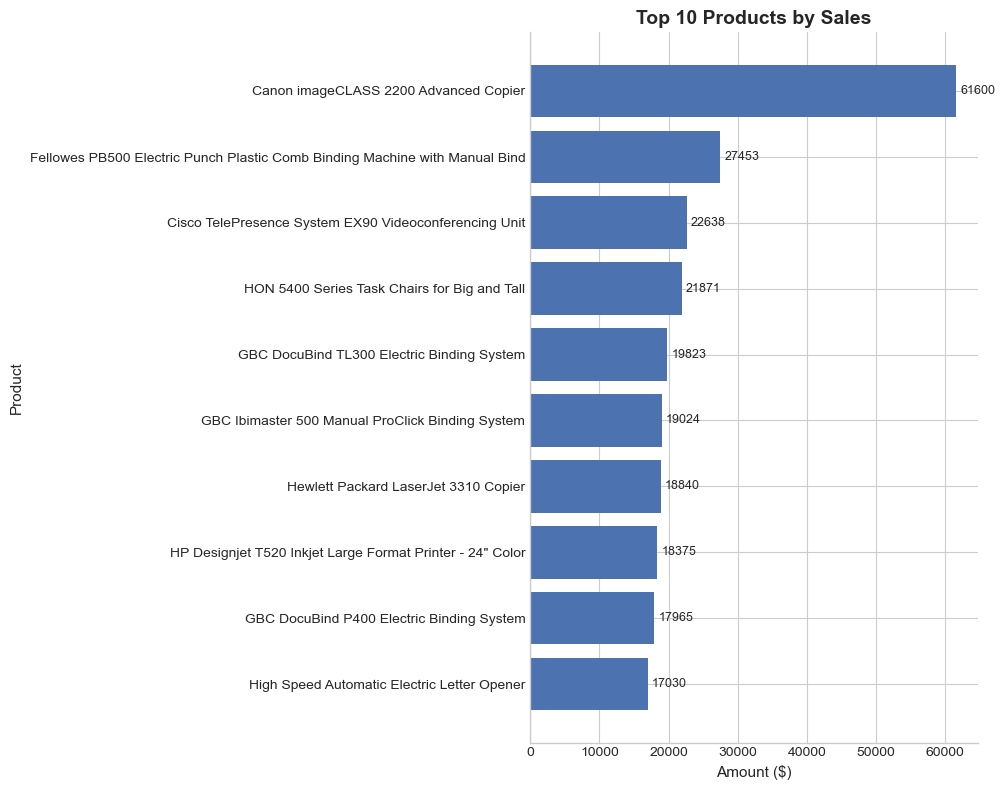

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))

bars1 = ax.barh(Top_10_Products["Product Name"], Top_10_Products["Sales"], color="#4C72B0")

ax.bar_label(bars1, fmt="%.0f", padding=3, fontsize=9)

ax.set_xlabel("Amount ($)", fontsize=11)
ax.set_ylabel("Product", fontsize=11)
ax.set_title("Top 10 Products by Sales", fontsize=14, fontweight="bold")
ax.invert_yaxis() 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

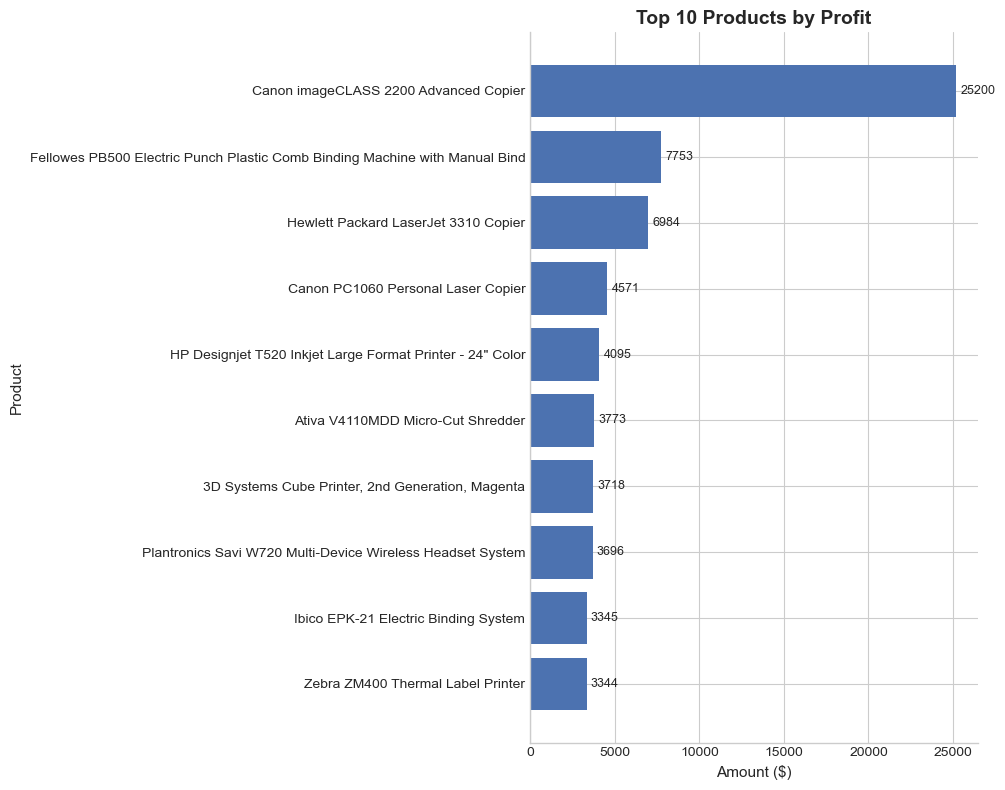

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))

bars1 = ax.barh(Top_10_Products_Profit["Product Name"], Top_10_Products_Profit["Profit"], color="#4C72B0")

ax.bar_label(bars1, fmt="%.0f", padding=3, fontsize=9)

ax.set_xlabel("Amount ($)", fontsize=11)
ax.set_ylabel("Product", fontsize=11)
ax.set_title("Top 10 Products by Profit", fontsize=14, fontweight="bold")
ax.invert_yaxis() 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Discount and Profitability Performance

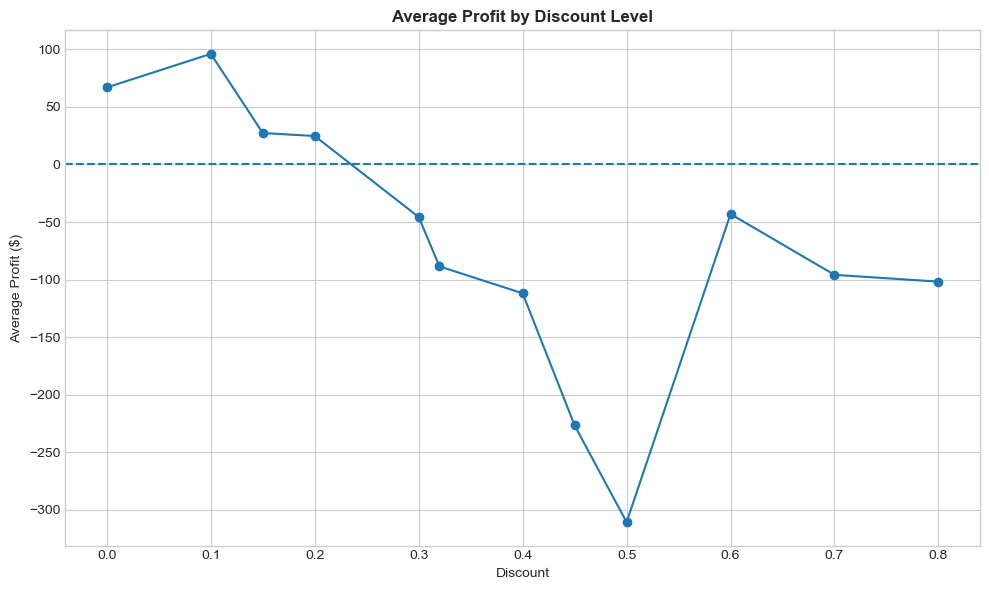

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_profit["Discount"],
    discount_profit["Profit"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Discount")
plt.ylabel("Average Profit ($)")
plt.title("Average Profit by Discount Level", fontweight = "bold")

plt.tight_layout()
plt.show()

### Regional Performance

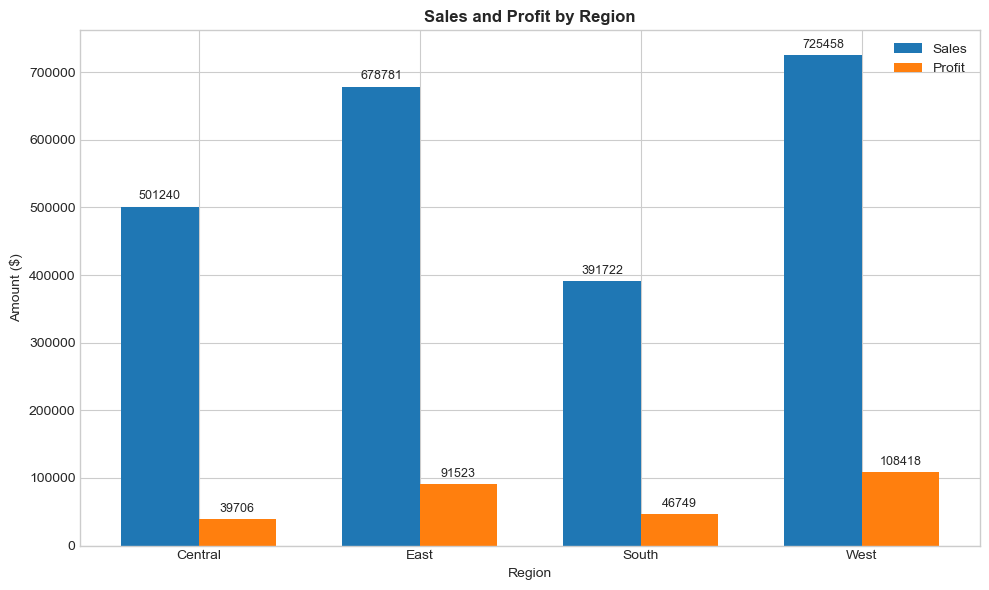

In [35]:
x = np.arange(len(region_comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_sales = ax.bar(
    x - width / 2,
    region_comparison["Sales"],
    width,
    label="Sales"
)

bars_profit = ax.bar(
    x + width / 2,
    region_comparison["Profit"],
    width,
    label="Profit"
)

ax.bar_label(bars_profit, fmt="%.0f", padding=3, fontsize=9)
ax.bar_label(bars_sales, fmt="%.0f", padding=3, fontsize=9)

ax.set_xlabel("Region")
ax.set_ylabel("Amount ($)")
ax.set_title("Sales and Profit by Region", fontweight = "bold")

ax.set_xticks(x)
ax.set_xticklabels(region_comparison["Region"])

ax.legend()
plt.tight_layout()
plt.show()








## 7. Key Insights

# Insights

## 1. Profitability and Discounts

The analysis shows a negative relationship between high discounts and profitability. Discounts of 30% or more are associated with negative average profit, while lower discounts generally maintain positive profitability. This suggests that high discounts should be applied carefully to avoid reducing profit margins.

## 2. Performance by Category

Technology is the best-performing category, generating the highest sales and the highest profit. Furniture also generates a significant amount of sales, but its profitability is considerably lower compared with Technology and Office Supplies.

## 3. Regional Performance

The West region has the highest sales and profit, making it the strongest-performing region. In contrast, the Central region has the lowest profit margin, indicating that its sales are not being converted into profit as efficiently as in the other regions.

## 4. Seasonal Sales

Sales show a seasonal pattern. September, November, and December have the highest sales levels, while January and February have the lowest. This indicates that demand is stronger during certain periods of the year.

## 5. Product Performance

The Canon imageCLASS 2200 Advanced Copier is the product with the highest total sales in the dataset. However, sales alone do not necessarily indicate the most profitable product, so product performance should also be evaluated based on total profit.

## 8. Recommendations

### Recommendations

1. **Review high-discount strategies:** Discounts of 30% or more were associated with negative average profit. The company should evaluate whether high discounts are generating enough additional sales to justify the reduction in profitability.

2. **Focus on profitable categories:** Technology showed the strongest overall performance in both sales and profit. The company could prioritize strategies that maintain or expand this category's performance.

3. **Investigate Furniture profitability:** Furniture generated significant sales but considerably lower profitability. Further analysis of sub-categories, discounts, and individual products could help identify the causes.

4. **Improve Central region profitability:** The Central region showed the lowest profit margin. The company should investigate pricing, discounting, product mix, and operating factors in this region.

5. **Plan around seasonal demand:** Higher sales during September, November, and December could be used to improve inventory planning and marketing strategies.

## 9. Conclusion

## Conclusion

The analysis of the Superstore sales dataset provided useful information about the company's sales performance, profitability, customers, products, categories, and regions.

Technology was identified as the strongest-performing category because it generated both the highest sales and the highest profit. On the other hand, Furniture generated a considerable amount of sales but showed much lower profitability, suggesting that this category should be analyzed more carefully.

One of the most important findings was the relationship between discounts and profitability. Higher discounts were associated with lower average profits, and discounts of 30% or more resulted in negative average profit in the analyzed data. Therefore, the company should carefully evaluate the use of high discounts.

The analysis also identified seasonal variations in sales. September, November, and December recorded the highest sales, while January and February had the lowest levels. This information could help the company plan inventory, marketing campaigns, and promotional strategies according to periods of higher and lower demand.

From a regional perspective, the West region showed the strongest overall performance, while the Central region had the lowest profit margin. This suggests that the company should investigate the factors affecting profitability in the Central region.

Overall, the analysis demonstrates that business decisions should not be based only on sales volume. Profitability, discounts, seasonality, product performance, and regional differences should also be considered to develop more effective commercial strategies.
